# Computing for Economists: Derivative-Free and Constrained Optimization
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import time

## Exercise: Combining Optimization Methods

For global optimization, sometimes we need to combine optimization methods - for example, using grid search first and then locally optimizing.

1. <font color = 'orange'> [AI Edit & Human Review]</font> Write a grid search function that takes the bounds and step size as inputs, and outputs the best values (for a minimization problem).

In [2]:
def grid_search(func, lower_bounds, upper_bounds, step_sizes):
    """
    Perform a grid search to find the points that minimize the given function.

    Parameters:
    - func: The function to be optimized. It should take a single argument: a NumPy array of parameter values.
    - lower_bounds: An array of lower bounds for each parameter.
    - upper_bounds: An array of upper bounds for each parameter.
    - step_sizes: An array of step sizes for each parameter.

    Returns:
    - A list of points (as NumPy arrays) that minimize the function.
    """
    # Ensure input arrays are NumPy arrays for element-wise operations
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    step_sizes = np.array(step_sizes)

    # Generate grid points
    grid_points = np.mgrid[[slice(low, high, step) for low, high,
                            step in zip(lower_bounds, upper_bounds, step_sizes)]]
    grid_points = grid_points.reshape(len(lower_bounds), -1).T

    # Evaluate the function at each grid point and find the minimum value
    func_values = np.array([func(point) for point in grid_points])
    min_points = grid_points[func_values == func_values.min()]

    return min_points

2.   <font color='red'> [Write it yourself]</font> Minimize the Eggholder function, using whichever of the local optimization methods in SciPy's library you think is best-suited for this problem. Try at least three different starting values. How do the results compare to the true solution $(512, 404.2319)$?

$$f(x, y) = -(y + 47) \sin\left(\sqrt{\left|\frac{x}{2} + (y + 47)\right|}\right) - x \sin\left(\sqrt{\left|x - (y + 47)\right|}\right)
\hspace{0.5cm} \text{for} \hspace{0.5cm} -512 \leq x,y \leq 512$$

In [3]:
def eggholder(x):
    x, y = x[0], x[1]
    term1 = -(y + 47) * np.sin(np.sqrt(np.abs(x/2 + y + 47)))
    term2 = -x * np.sin(np.sqrt(np.abs(x - (y + 47))))
    return term1 + term2

In [4]:
# Try random initial guesses
initial_guesses = [[0, 0], [-200, 200], [500, 500]]
for x0 in initial_guesses:
    result = opt.minimize(eggholder, x0, method='L-BFGS-B', bounds=((-512, 512), (-512, 512)))
    print("Optimizer Result: ", result.x, ", Function Value: ", result.fun)

# Real solution
egg_solution = [512, 404.2319]
print("Actual Result: ", egg_solution, ", Function Value: ", eggholder(egg_solution))

Optimizer Result:  [ 8.45694116 15.65092663] , Function Value:  -66.84371732944741
Optimizer Result:  [-242.9791677   274.38032318] , Function Value:  -559.7868565498718
Optimizer Result:  [439.48101284 453.97746477] , Function Value:  -935.3379515602685
Actual Result:  [512, 404.2319] , Function Value:  -959.6406627106155


3. <font color = 'orange'> [AI Edit & Human Review]</font> Generate plotting code that will help you visualize this function. Plot the point (512, 404.2319). Based on what you see, what do you think is going on?

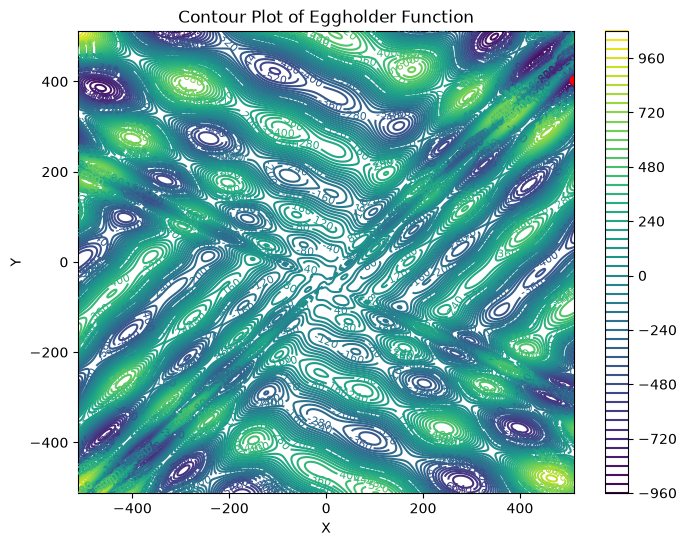

In [5]:
# Plot contour map of function
X_values = np.linspace(-512, 512, 1000)
Y_values = np.linspace(-512, 512, 1000)
X_grid, Y_grid = np.meshgrid(X_values, Y_values)
func_grid = eggholder([X_grid, Y_grid])

plt.figure(figsize=(8, 6))
contours = plt.contour(X_grid, Y_grid, func_grid, 50, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8, fmt="%1.0f")

# Plot the solution
plt.plot(egg_solution[0], egg_solution[1], 'ro')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Contour Plot of Eggholder Function')
plt.colorbar(contours)

***Solution:*** Based on the plot, the problem is plagued by local minima and maxima. For a derivative-based method such as BFGS, this will make it very dependent on the initial value. The solution is also not an interior point (which can be handled by L-BFGS-B). 

4. <font color = 'orange'> [AI Edit & Human Review]</font> Now combine grid search with your choice of optimization method (using SciPy's built-in library) and time it. Use a grid search of step size 5 then adjust the step size to 3.

In [6]:
def combine_grid_search_and_local_opt(function, lower_bounds, upper_bounds, step_size, method, opt_bounds):
    """
    Combines grid search with local optimization to find the minimum of a given function.

    First, it performs a grid search over a specified range and step size to find initial guesses.
    Then, it uses these guesses to perform local optimization using a specified method.

    Parameters:
    - function (callable): The objective function to be minimized.
    - lower_bounds (list or array): Lower bounds of the search space for each dimension.
    - upper_bounds (list or array): Upper bounds of the search space for each dimension.
    - step_size (list or array): The step size for the grid search for each dimension.
    - method (str): The optimization method to use for local optimization in scipy.optimize.minimize (e.g. 'Nelder-Mead', 'L-BFGS-B').
    - opt_bounds (list of tuples): Bounds for local optimization, specified as pairs (min, max)
      for each dimension.

    Prints:
    - The optimal points found by grid search, the time taken for grid search.
    - The optimal point found by local optimization, the method used, the time taken, and the
      function value at this point.
    - A message if local optimization fails for a particular starting point.
    """
    # Find initial guesses based on grid search
    start_time = time.time()
    initial_guesses = grid_search(function, lower_bounds, upper_bounds, step_size)
    your_time = time.time() - start_time
    print(f"Optimal Grid Search Points: {initial_guesses}, Time taken: {your_time}")

    optimal_x = np.ones(len(upper_bounds))
    function_val = 1e8

    for initial_guess in initial_guesses:
        # Perform optimization
        start_time = time.time()
        result = opt.minimize(function, initial_guess, method=method, bounds=opt_bounds)
        your_time = time.time() - start_time

        # Display the optimal production levels and the maximum profit
        if result.success:
            if function_val > result.fun:
                optimal_x = result.x
                function_val = result.fun
        else:
            print(f"Optimization failed")

    print(f"Optimality: {optimal_x} using method " + method + f", Time taken: {your_time}")
    print(f"Function Value: {function_val}")

In [7]:
# Define a list of initial guesses using grid search:
lower_bounds = [-512, -512]
upper_bounds = [512, 512]
optimizer_bounds = ((-512, 512), (-512, 512))

step_size = [5, 5]
combine_grid_search_and_local_opt(eggholder, lower_bounds, upper_bounds, step_size, 'L-BFGS-B', optimizer_bounds)

Optimal Grid Search Points: [[483 433]], Time taken: 0.04112410545349121
Optimality: [479.04533497 434.5058076 ] using method L-BFGS-B, Time taken: 0.0007257461547851562
Function Value: -955.25515214342


In [8]:
step_size = [3, 3]
combine_grid_search_and_local_opt(eggholder, lower_bounds, upper_bounds, step_size, 'L-BFGS-B', optimizer_bounds)

Optimal Grid Search Points: [[511 403]], Time taken: 0.11347317695617676
Optimality: [512.         404.23180049] using method L-BFGS-B, Time taken: 0.0003650188446044922
Function Value: -959.6406627208266


5. <font color = '701B1B'> [Conceptual]</font> Compare the results from 3. and 4., and comment on computational accuracy and speed.



**Solution:** There is a trade-off between time and accuracy. A finer grid takes longer to evaluate (here it takes over three times as long -- and this is just slightly tuning the size of the grid size to be 3 instead of 5 without an increase in dimensionality). However, the answer in the second case is much more accurate (in fact, the correct solution) since we have a better initial guess for our local optimizer. Local optimization with derivatives is generally very fast, so that's not the bottleneck.

6. <font color = 'purple'> [AI Edit & Design Tests]</font> Now optimize the following function $f:\mathbb{R}^n \rightarrow \mathbb{R}$. Use your grid search function paired with a local optimizer to find the global minimum $(-2.903534, ..., -2.903534)$. Write a test to check whether the AI-generated code is behaving correctly.

$$f(\mathbf{x}) = \frac{1}{2} \sum_{i=1}^{n} \left(x_i^4 - 16x_i^2 + 5x_i \right) \hspace{0.5cm} \text{for} \hspace{0.5cm} -5 \leq x_i \leq 5$$

Compute with $n = 3$ and $n=5$. What happens to the computational accuracy and time? What do you think will happen with $n=10$?

In [9]:
def styblinski_tang(x):
    return 0.5 * np.sum(x**4 - 16*x**2 + 5*x)

# Calculate :
for n in [3, 5]:
    lower_bounds = [-5] * n
    upper_bounds = [5] * n
    optimizer_bounds = ((-5, 5),) * n
    step_size = [0.5] * n

    combine_grid_search_and_local_opt(styblinski_tang, lower_bounds, upper_bounds, step_size, 'L-BFGS-B', optimizer_bounds)

Optimal Grid Search Points: [[-3. -3. -3.]], Time taken: 0.01685500144958496
Optimality: [-2.90353393 -2.90353393 -2.90353393] using method L-BFGS-B, Time taken: 0.0004200935363769531
Function Value: -117.49849711131372


Optimal Grid Search Points: [[-3. -3. -3. -3. -3.]], Time taken: 6.48459792137146
Optimality: [-2.90353393 -2.90353393 -2.90353393 -2.90353401 -2.90353401] using method L-BFGS-B, Time taken: 0.0005440711975097656
Function Value: -195.83082851885652


**Solution:** This problem demonstrates the curse of dimensionality. Searching over $R^3$ vs. $R^5$ increases the grid search time by over 200 times! We do not even keep $n=10$ in the solutions because the grid search uses up all of the colab RAM and crashes the notebook. Local optimization and accuracy are not compromised (as expected).

## Exercise: Root-Finding vs. Optimization

Take the standard utility maximizing agent with Cobb-Douglas preferences subject to a budget constraint:
$$U(X,Y) = X^\alpha Y^\beta \hspace{0.5cm} s.t. \hspace{0.5cm} P_X X + P_Y Y \leq B$$

1.   <font color = '701B1B'> [Conceptual]</font> Write out the Lagrangian to the problem, and derive the first-order conditions.



**Solution:**
$$\mathcal{L}(X, Y, \lambda) = X^\alpha Y^\beta + \lambda(B - P_X X - P_Y Y)$$

First-order conditions:
$$[X]: \alpha X^{\alpha - 1} Y^\beta - \lambda P_X = 0$$
$$[Y]: \beta Y^{\beta - 1} X^\alpha - \lambda P_Y = 0$$
$$[\lambda]: B - P_X X - P_Y Y = 0$$

Let $\alpha = 0.65, \beta = 0.35, B = 100, P_X = 9, P_Y = 3$.

2.   <font color = 'orange'> [AI Edit & Human Review]</font> Use one of SciPy's root-solvers to solve for the optimal $(X, Y)$. Try 1000 random initial values and output the minimum and maximum solution. How long does it take in total?


In [10]:
# Parameters
alpha = 0.65
beta = 0.35
B = 100  # Budget
P_X = 9  # Price of X
P_Y = 3  # Price of Y

In [11]:
# Define the system of equations derived from the Lagrangian
def first_order_conditions(vars):
    X, Y, lambda_ = vars
    foc1 = alpha * (X**(alpha-1)) * (Y**beta) - lambda_ * P_X
    foc2 = beta * (X**alpha) * (Y**(beta-1)) - lambda_ * P_Y
    foc3 = B - P_X*X - P_Y*Y
    return [foc1, foc2, foc3]

# Initial guesses for X, Y, and lambda
N = 1000
initial_guesses = np.random.uniform(1, 30, (N, 3))

total_time = 0
min_sol = np.ones(3) * 1e6
max_sol = np.zeros(3)

# Solve the system of equations
for x0 in initial_guesses:
    start_time = time.time()
    solution = opt.fsolve(first_order_conditions, x0)
    your_time = time.time() - start_time

    # Update min, max, and time
    total_time += your_time
    min_sol = np.minimum(min_sol, solution)
    max_sol = np.maximum(max_sol, solution)

np.testing.assert_allclose(min_sol, max_sol, rtol=1e-8, atol=1e-8)
print(f"Optimal X, Y, and Lagrange multiplier: {min_sol}, time for {N} initial values = {total_time}")

Optimal X, Y, and Lagrange multiplier: [ 7.22222222 11.66666667  0.08542155], time for 1000 initial values = 0.013142824172973633


3.   <font color = 'orange'> [AI Edit & Human Review]</font> Now consider the problem as a constrained optimization. Pick one of Python's built-in constrained optimizers, and have the AI generate code that uses it. Which constrained optimizer did you use and why? How long does it take compared to treating the problem as root-solving and why? For comparability, also try the problem with 1000 different initial guesses.

In [12]:
def utility_function(X, Y):
    return X**alpha * Y**beta

def linear_budget(X, Y):
    return B - (P_X * X + P_Y * Y)

In [13]:
def maximize_utility(utility_func, budget_cons, method, initial_guesses):
    """
    Solves the utility maximization problem with a budget constraint.

    Parameters:
    - utility_func: A function representing the utility as a function of quantities of goods, U(X, Y).
    - budget_cons: A function representing the surplus budget leftover (from the budget constraint)
    - method: Choice of constrained optimization algorithm ('COBYLA' or 'SLSQP')
    - initial_guesses: array of initial values for optimization

    Returns:
    - A dictionary with the optimized quantities of goods and the maximum utility and time of total computation for all initial values.
    """
    # Constraint dictionary for scipy.optimize.minimize
    cons = ({'type': 'ineq', 'fun': lambda XY: budget_cons(XY[0], XY[1])})

    # Objective function to be minimized
    objective = lambda XY: -utility_func(XY[0], XY[1])  # Minimize the negative utility

    # Initializing
    N = initial_guesses.shape[0]
    num_var = initial_guesses.shape[1]

    total_time = 0
    min_sol = np.ones(num_var) * 1e6
    max_sol = np.zeros(num_var)

    # Optimize
    for x0 in initial_guesses:
        start_time = time.time()
        solution = opt.minimize(objective, x0, constraints=cons, method=method)
        your_time = time.time() - start_time

        # Update min, max, and time
        total_time += your_time
        min_sol = np.minimum(min_sol, solution.x)
        max_sol = np.maximum(max_sol, solution.x)

    np.testing.assert_allclose(min_sol, max_sol, rtol=1e-2, atol=1e-2)
    max_utility = -solution.fun
    print('Optimized using', method, 'quantities:', solution.x, 'utility:', max_utility, f'time for {N} initial guesses:', total_time)
    return solution.x

In [14]:
# Initial guesses for X, Y, and lambda
N = 1000
initial_guesses = np.random.uniform(1, 15, (N, 2))

slsqp = maximize_utility(utility_function, linear_budget, 'SLSQP', initial_guesses)
cobyla = maximize_utility(utility_function, linear_budget, 'COBYLA', initial_guesses)

Optimized using SLSQP quantities: [ 7.22214005 11.66691318] utility: 8.542154595468258 time for 1000 initial guesses: 0.3951385021209717


/var/folders/l0/k28_dxz966g3r67w8d1g2csc0000gn/T/ipykernel_65991/3757278501.py:2: RuntimeWarning: invalid value encountered in scalar power
  return X**alpha * Y**beta


Optimized using COBYLA quantities: [ 7.22221865 11.6666774 ] utility: 8.542154596493074 time for 1000 initial guesses: 9.980493068695068


**Solution:** SLSQP and COBYLA take almost 50 times and over 500 times longer than root-solving (on my machine), respectively. The root-solving case involves finding the derivative of nicely behaved functions which will lead to quick convergence (as is this case with a nicely behaved utility maximization). Constrained optimization problems involve a series of optimization problems to solve. Within each step of SLSQP, the gradient and the Hessian are calculated to approximate the problem, and within each updating step, active set and Newtonian methods are applied. The original solutions claimed: COBYLA is quicker in this case since it revolves around taking linear approximations based on the simplex (and we have a fairly easy set-up in this case), but successive optimization still must take place to update the simplex vertices (e.g. with Nelder-Mead). However, I find that COBYLA is slower.

In addition to the time, students may also notice that the answer varied more in constrained optimization between different initial guesses (the difference between the min and max is larger than 0.001), and the range of the initial value draw needs to be smaller than that for root-solving for the optimizer to not encounter a runtime warning. We are working with successive approximations for both constrained optimization methods.

Now suppose we have a non-linear budget constraint. Instead, we receive bulk discounts for purchasing $X$ above a threshold $\overline{Q}_X$. We have a piece-wise budget constraint for the cost of $X$ given by the following:

\begin{equation*}
Cost(X) =
\begin{cases}
P_{X0} X & \text{if } X \leq \overline{X}_1 \\
P_{X0} \overline{X}_1 + P_{X1} (X - \overline{X}_1) & \text{if } \overline{X}_1 < X \leq \overline{X}_2 \\
P_{X0} \overline{X}_1 + P_{X1} (\overline{X}_2 - \overline{X}_1) + P_{X2} (X - \overline{X}_2)& \text{if } \overline{X}_2 < X
\end{cases}
\end{equation*}

The new budget constraint is then given by:
$$Cost(X) + P_Y Y \leq B$$

4. <font color = 'orange'> [AI Edit & Human Review]</font> Solve the utility-maximizing levels of $(X, Y)$ subject to the new budget constraint with your favorite constrained optimizer using the following parameter values. For this problem, try only two initial values and one at a time: $[1, 1]$ and $[10, 10]$.

5. <font color = '701B1B'> [Conceptual]</font> What functional form properties of piecewise budget constraints can lead to problems in numerical optimization?

**Hint:** <font color = 'orange'> [AI Edit & Human Review]</font> A plot may be helpful to answer this. You should use AI to help you generate a plot that shows you what you need to see.

In [15]:
# New parameters
P_X0 = P_X
P_X1 = 6.5  # Discounted price for X beyond the first threshold
P_X2 = 3.5  # Further discounted price for X beyond the second threshold
X1_threshold = 5
X2_threshold = 10

# New budget constraint
def piecewise_budget(X, Y):
    if X <= X1_threshold:
        cost_X = P_X0 * X
    elif X1_threshold < X <= X2_threshold:
        cost_X = P_X0 * X1_threshold + P_X1 * (X - X1_threshold)
    else:
        cost_X = P_X0 * X1_threshold + P_X1 * (X2_threshold - X1_threshold) + P_X2 * (X - X2_threshold)

    return B - (cost_X + P_Y * Y)

In [16]:
initial_guess = np.array([[1, 1]])

solution_slsqp1 = maximize_utility(utility_function, piecewise_budget, 'SLSQP', initial_guess)
solution_cobyla1 = maximize_utility(utility_function, piecewise_budget, 'COBYLA', initial_guess)

Optimized using SLSQP quantities: [10.67828298  6.70866986] utility: 9.075042627998089 time for 1 initial guesses: 0.0005850791931152344
Optimized using COBYLA quantities: [ 8.74999619 10.20834158] utility: 9.235053790870372 time for 1 initial guesses: 0.014187097549438477


/var/folders/l0/k28_dxz966g3r67w8d1g2csc0000gn/T/ipykernel_65991/3757278501.py:2: RuntimeWarning: invalid value encountered in scalar power
  return X**alpha * Y**beta


In [17]:
initial_guess = np.array([[10, 10]])

solution_slsqp2 = maximize_utility(utility_function, piecewise_budget, 'SLSQP', initial_guess)
solution_cobyla2 = maximize_utility(utility_function, piecewise_budget, 'COBYLA', initial_guess)

Optimized using SLSQP quantities: [ 8.75008302 10.20815345] utility: 9.235053790099915 time for 1 initial guesses: 0.0005278587341308594
Optimized using COBYLA quantities: [ 8.74998905 10.20835707] utility: 9.235053790858553 time for 1 initial guesses: 0.011665105819702148


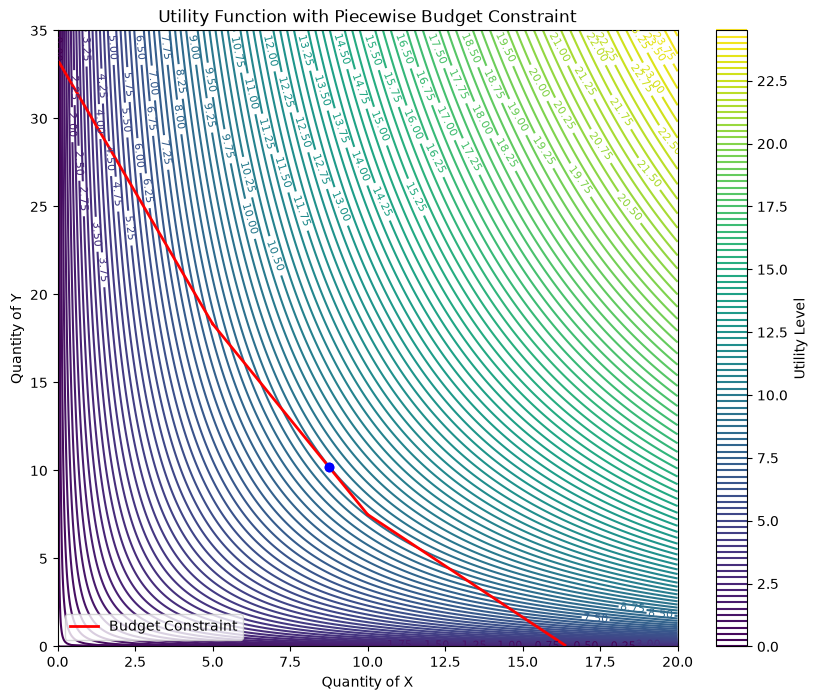

In [18]:
# Generate grid for contour plot
x_range = np.linspace(0, 20, 400)
y_range = np.linspace(0, 35, 400)
X, Y = np.meshgrid(x_range, y_range)
U = utility_function(X, Y)

# Plotting the utility function as contour map
plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, U, levels=100, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Piecewise budget constraint (solve for Y)
x_segment1 = np.linspace(0, X1_threshold, 100)
y_segment1 = (B - P_X0 * x_segment1) / P_Y

x_segment2 = np.linspace(X1_threshold, X2_threshold, 100)
y_segment2 = (B - P_X0 * X1_threshold - P_X1 * (x_segment2 - X1_threshold)) / P_Y

x_segment3 = np.linspace(X2_threshold, 20, 100)
y_segment3 = np.where((arr := np.maximum((B - P_X0 * X1_threshold - P_X1 * (X2_threshold - X1_threshold) - P_X2 * (x_segment3 - X2_threshold)) / P_Y, 0)) == 0, np.nan, arr)

# Plotting the piecewise budget line
plt.plot(x_segment1, y_segment1, 'r-', linewidth=2)
plt.plot(x_segment2, y_segment2, 'r-', linewidth=2)
plt.plot(x_segment3, y_segment3, 'r-', linewidth=2, label='Budget Constraint')

# Plot the solution
plt.plot(solution_cobyla1[0], solution_cobyla1[1], 'bo')
plt.plot(solution_cobyla2[0], solution_cobyla2[1], 'bo')

plt.xlabel('Quantity of X')
plt.ylabel('Quantity of Y')
plt.title('Utility Function with Piecewise Budget Constraint')
plt.legend()
plt.colorbar(contour, label='Utility Level')
plt.show()


**Solution:** The main problem is that the budget set is no longer convex, which can lead to multiple solutions. One can imagine a utility curve that is drawn through both the two solution points. Depending on where the initial value is, either optimum can be reached. This happens regardless of which constrained optimization algorithm is used (COBYLA or SLSQP).

# Submission ⭐

Congratulations you finished this module! We will handle all exercise submissions on GitHub classroom. In order to access this assignment, you should already have a GitHub account with an associated repository unique to you. Please submit the assignment in that repository.